In [ ]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the uploaded CSV file into a pandas DataFrame
  df = pd.read_csv(io.BytesIO(uploaded[fn]))

  # Now you can work with the DataFrame 'df'
  print(df.head()) # Example: Print the first few rows


Saving NEW DATASHEET - Sheet1.csv to NEW DATASHEET - Sheet1.csv
User uploaded file "NEW DATASHEET - Sheet1.csv" with length 121322 bytes
   Synthesizable Material ID  Formula Crystal System Space Group Symbol  \
0          False    mp-23558  Ag2BiO3   Orthorhombic               Pnn2   
1          False    mp-29163  Ag2TeS3     Monoclinic                 Cc   
2           True  mp-1229128   Ag3PO4       Trigonal                R3c   
3           True   mp-632480    Ag3SI      Triclinic                 P1   
4          False     mp-4515  Ag3SbS3       Trigonal                R3c   

   Space Group Number  Sites  Energy Above Hull  Formation Energy  \
0                  34     24           0.000000          -0.92342   
1                   9     12           0.000000          -0.07847   
2                 161     16           0.000000          -1.40720   
3                   1      5           0.073682          -0.26354   
4                 161     14           0.008792          -0.19758  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Assuming 'df' is your DataFrame loaded from the uploaded file

# Preprocess the data
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
X = df[numerical_features].drop('Band Gap', axis=1)  # Features
y = df['Band Gap']  # Target variable

# Handle missing values (replace with mean for simplicity, consider other methods)
X = X.fillna(X.mean())


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 0.701871827247633
R-squared (R²): 0.6724570474102143


In [ ]:
# Assuming 'df' is your DataFrame loaded from the uploaded file (from previous code)

# Preprocess the data
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
X = df[numerical_features].drop('Band Gap', axis=1)  # Features
y = df['Band Gap']  # Target variable

# Handle missing values (replace with mean for simplicity, consider other methods)
X = X.fillna(X.mean())


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 0.701871827247633
R-squared (R²): 0.6724570474102143


Saving Copy of NEW DATASHEET - Sheet1.csv to Copy of NEW DATASHEET - Sheet1.csv
User uploaded file "Copy of NEW DATASHEET - Sheet1.csv" with length 120098 bytes
   Synthesizable Material ID  Formula Crystal System Space Group Symbol  \
0          False    mp-23558  Ag2BiO3   Orthorhombic               Pnn2   
1          False    mp-29163  Ag2TeS3     Monoclinic                 Cc   
2           True  mp-1229128   Ag3PO4       Trigonal                R3c   
3           True   mp-632480    Ag3SI      Triclinic                 P1   
4          False     mp-4515  Ag3SbS3       Trigonal                R3c   

   Space Group Number  Sites  Energy Above Hull  Formation Energy  \
0                  34     24           0.000000          -0.92342   
1                   9     12           0.000000          -0.07847   
2                 161     16           0.000000          -1.40720   
3                   1      5           0.073682          -0.26354   
4                 161     14           0.00

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

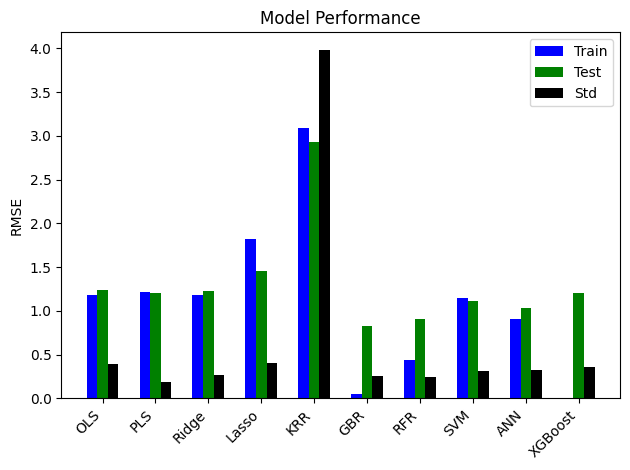

Best Model: GBR with Test RMSE: 0.8220286421166456


In [ ]:
from google.colab import files
import io
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.BytesIO(uploaded[fn]))
  print(df.head())

# Preprocessing
numerical_cols = df.select_dtypes(include=np.number).columns
X = df[numerical_cols].drop('Band Gap', axis=1)
y = df['Band Gap']
X = X.fillna(X.mean())
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Models
models = {
    'OLS': LinearRegression(),
    'PLS': PLSRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'KRR': KernelRidge(),
    'GBR': GradientBoostingRegressor(),
    'RFR': RandomForestRegressor(),
    'SVM': SVR(),
    'ANN': MLPRegressor(),
    'XGBoost': xgb.XGBRegressor()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    std_rmse = np.std(-cv_scores)
    results[name] = {'train': rmse_train, 'test': rmse_test, 'std': std_rmse}

# Plotting
width = 0.2
x = np.arange(len(models))
plt.bar(x - width, [results[name]['train'] for name in models], width, label='Train', color='blue')
plt.bar(x, [results[name]['test'] for name in models], width, label='Test', color='green')
plt.bar(x + width, [results[name]['std'] for name in models], width, label='Std', color='black')

plt.xticks(x, models.keys(), rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title('Model Performance')
plt.legend()
plt.tight_layout()
plt.show()

# Best Model
best_model = min(results, key=lambda k: results[k]['test'])
print(f'Best Model: {best_model} with Test RMSE: {results[best_model]["test"]}')

Saving Copy of NEW DATASHEET - Sheet1.csv to Copy of NEW DATASHEET - Sheet1 (1).csv
User uploaded file "Copy of NEW DATASHEET - Sheet1 (1).csv" with length 120098 bytes
   Synthesizable Material ID  Formula Crystal System Space Group Symbol  \
0          False    mp-23558  Ag2BiO3   Orthorhombic               Pnn2   
1          False    mp-29163  Ag2TeS3     Monoclinic                 Cc   
2           True  mp-1229128   Ag3PO4       Trigonal                R3c   
3           True   mp-632480    Ag3SI      Triclinic                 P1   
4          False     mp-4515  Ag3SbS3       Trigonal                R3c   

   Space Group Number  Sites  Energy Above Hull  Formation Energy  \
0                  34     24           0.000000          -0.92342   
1                   9     12           0.000000          -0.07847   
2                 161     16           0.000000          -1.40720   
3                   1      5           0.073682          -0.26354   
4                 161     14       

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

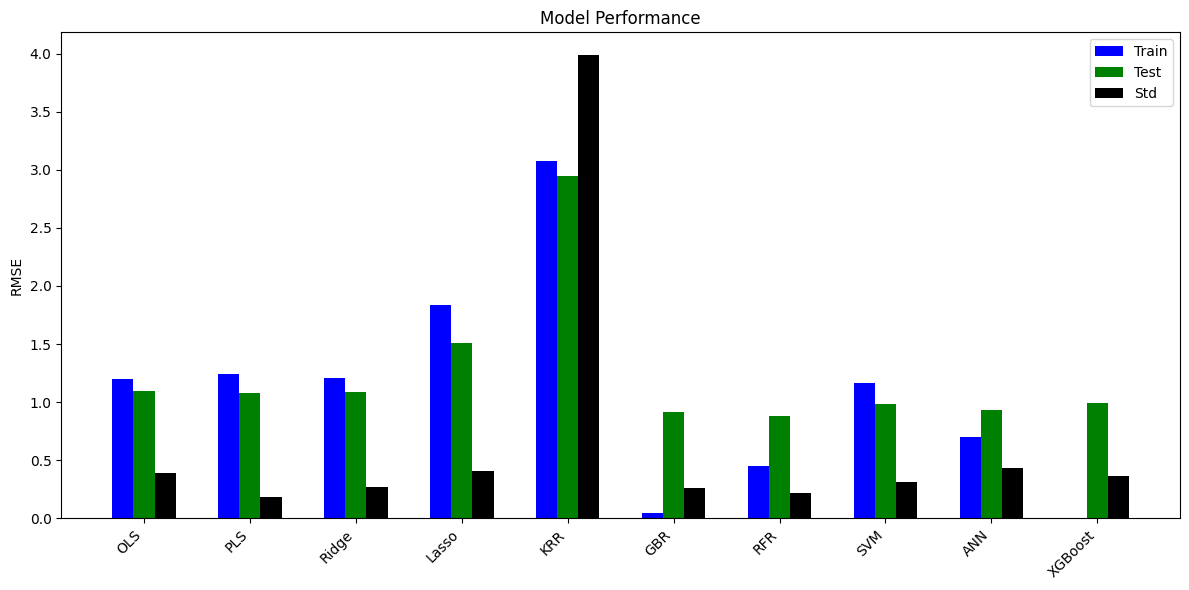

Best Model: RFR with Test RMSE: 0.8805828331116091


In [ ]:
from google.colab import files
import io
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.BytesIO(uploaded[fn]))
  print(df.head())

# Preprocessing
numerical_cols = df.select_dtypes(include=np.number).columns
X = df[numerical_cols].drop('Band Gap', axis=1)
y = df['Band Gap']
X = X.fillna(X.mean())
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    'OLS': LinearRegression(),
    'PLS': PLSRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'KRR': KernelRidge(),
    'GBR': GradientBoostingRegressor(),
    'RFR': RandomForestRegressor(),
    'SVM': SVR(),
    'ANN': MLPRegressor(max_iter=500), # Increased max_iter for convergence
    'XGBoost': xgb.XGBRegressor()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    std_rmse = np.std(-cv_scores)
    results[name] = {'train': rmse_train, 'test': rmse_test, 'std': std_rmse}

# Plotting
width = 0.2
x = np.arange(len(models))
plt.figure(figsize=(12,6)) # Increased figure size for better visibility
plt.bar(x - width, [results[name]['train'] for name in models], width, label='Train', color='blue')
plt.bar(x, [results[name]['test'] for name in models], width, label='Test', color='green')
plt.bar(x + width, [results[name]['std'] for name in models], width, label='Std', color='black')

plt.xticks(x, models.keys(), rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title('Model Performance')
plt.legend()
plt.tight_layout()
plt.show()

# Best Model
best_model = min(results, key=lambda k: results[k]['test'])
print(f'Best Model: {best_model} with Test RMSE: {results[best_model]["test"]}')

Saving Copy of NEW DATASHEET - Sheet1.csv to Copy of NEW DATASHEET - Sheet1 (2).csv
User uploaded file "Copy of NEW DATASHEET - Sheet1 (2).csv" with length 120098 bytes
   Synthesizable Material ID  Formula Crystal System Space Group Symbol  \
0          False    mp-23558  Ag2BiO3   Orthorhombic               Pnn2   
1          False    mp-29163  Ag2TeS3     Monoclinic                 Cc   
2           True  mp-1229128   Ag3PO4       Trigonal                R3c   
3           True   mp-632480    Ag3SI      Triclinic                 P1   
4          False     mp-4515  Ag3SbS3       Trigonal                R3c   

   Space Group Number  Sites  Energy Above Hull  Formation Energy  \
0                  34     24           0.000000          -0.92342   
1                   9     12           0.000000          -0.07847   
2                 161     16           0.000000          -1.40720   
3                   1      5           0.073682          -0.26354   
4                 161     14       

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perce

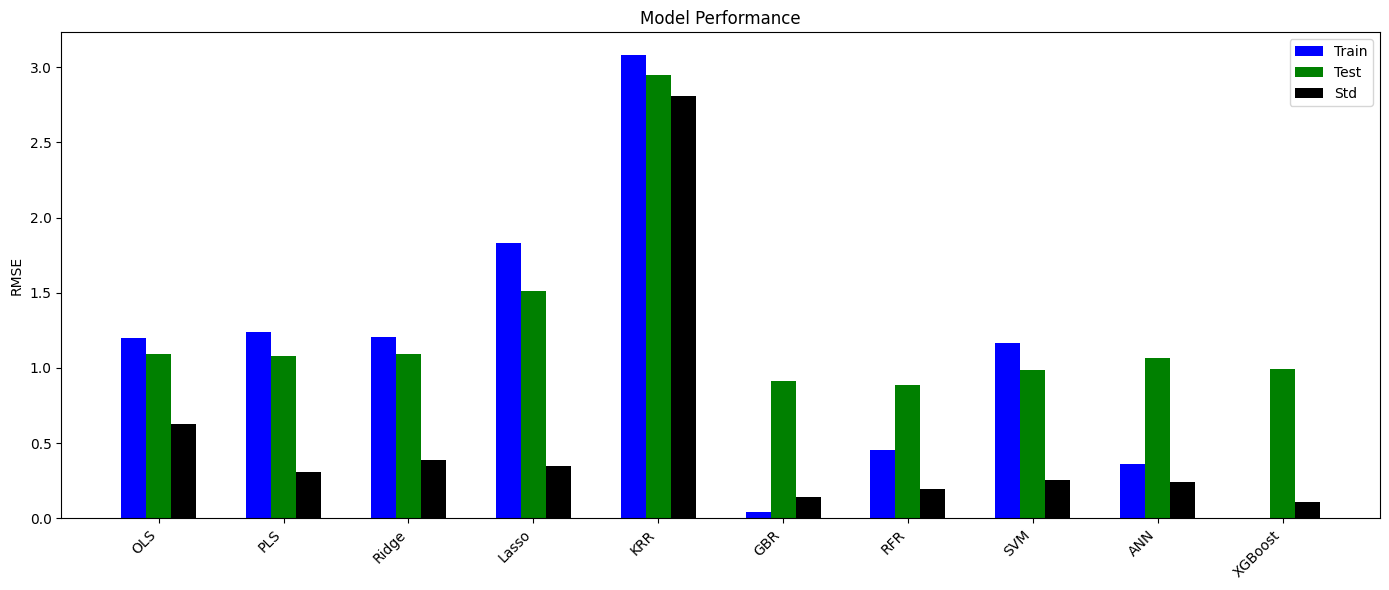

Best Model: RFR with Test RMSE: 0.8867912951369868


In [ ]:
from google.colab import files
import io
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import matplotlib.pyplot as plt

# Upload the dataset
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(df.head())


# Preprocessing
def preprocess_data(df, target_column='Band Gap'):
    numerical_cols = df.select_dtypes(include=np.number).columns
    X = df[numerical_cols].drop(target_column, axis=1, errors='ignore') # Ignore if target not present
    y = df[target_column]

    # Handle missing values using median (more robust than mean)
    for col in X.columns:
        if X[col].isnull().any():
             X[col] = X[col].fillna(X[col].median())


    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X, y

X, y = preprocess_data(df) # Now uses the preprocess_data function
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models - with increased max_iter for MLPRegressor
models = {
    'OLS': LinearRegression(),
    'PLS': PLSRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'KRR': KernelRidge(),
    'GBR': GradientBoostingRegressor(),
    'RFR': RandomForestRegressor(),
    'SVM': SVR(),
    'ANN': MLPRegressor(max_iter=1000), # Increased for better convergence
    'XGBoost': xgb.XGBRegressor()
}


# Function to evaluate models and plot results
def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

        # Robust Cross Validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
        std_rmse = np.std(-cv_scores)

        results[name] = {'train': rmse_train, 'test': rmse_test, 'std': std_rmse}
    return results


results = evaluate_models(models, X_train, y_train, X_test, y_test)

# Plotting
width = 0.2
x = np.arange(len(models))

plt.figure(figsize=(14, 6))  # Adjust figure size as needed
plt.bar(x - width, [results[name]['train'] for name in models], width, label='Train', color='blue')
plt.bar(x, [results[name]['test'] for name in models], width, label='Test', color='green')
plt.bar(x + width, [results[name]['std'] for name in models], width, label='Std', color='black')


plt.xticks(x, models.keys(), rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title('Model Performance')
plt.legend()
plt.tight_layout()
plt.show()

# Find best model
best_model = min(results, key=lambda k: results[k]['test'])
print(f'Best Model: {best_model} with Test RMSE: {results[best_model]["test"]}')


Saving Copy of NEW DATASHEET - Sheet1.csv to Copy of NEW DATASHEET - Sheet1 (3).csv
User uploaded file "Copy of NEW DATASHEET - Sheet1 (3).csv" with length 120098 bytes
   Synthesizable Material ID  Formula Crystal System Space Group Symbol  \
0          False    mp-23558  Ag2BiO3   Orthorhombic               Pnn2   
1          False    mp-29163  Ag2TeS3     Monoclinic                 Cc   
2           True  mp-1229128   Ag3PO4       Trigonal                R3c   
3           True   mp-632480    Ag3SI      Triclinic                 P1   
4          False     mp-4515  Ag3SbS3       Trigonal                R3c   

   Space Group Number  Sites  Energy Above Hull  Formation Energy  \
0                  34     24           0.000000          -0.92342   
1                   9     12           0.000000          -0.07847   
2                 161     16           0.000000          -1.40720   
3                   1      5           0.073682          -0.26354   
4                 161     14       

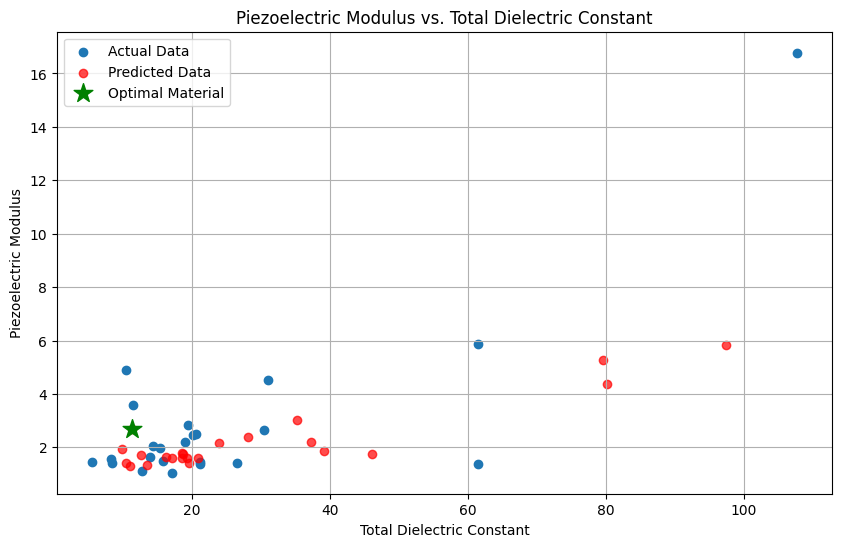

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Upload the dataset
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(df.head())

# Preprocessing
def preprocess_data(df, target_columns):
    # Select numerical features and handle missing values
    numerical_cols = df.select_dtypes(include=np.number).columns
    X = df[numerical_cols].drop(target_columns, axis=1, errors='ignore')
    for col in X.columns:
        if X[col].isnull().any():
             X[col] = X[col].fillna(X[col].median())
    # Scale numerical features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    y = df[target_columns]
    return X_scaled, y

# Define target columns
target_columns = ['Piezoelectric Modulus', 'Total Dielectric Constant']

# Preprocess the data
X, y = preprocess_data(df, target_columns)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42, n_estimators=100) # Increased n_estimators for better performance
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Generate the 2D scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test['Total Dielectric Constant'], y_test['Piezoelectric Modulus'], label='Actual Data')
plt.scatter(y_pred[:,1], y_pred[:,0], color='red', label='Predicted Data', alpha=0.7) # Added predicted data


# Find the optimal point (example - needs adjustment based on specific optimization goal)
# For example, you might want to find the material with the highest ratio of Piezoelectric Modulus to Total Dielectric Constant
optimal_index = np.argmax(y_pred[:, 0] / y_pred[:, 1]) # Example for maximization
optimal_point = y_pred[optimal_index]


plt.scatter(optimal_point[1], optimal_point[0], color='green', marker='*', s=200, label='Optimal Material')
plt.xlabel('Total Dielectric Constant')
plt.ylabel('Piezoelectric Modulus')
plt.title('Piezoelectric Modulus vs. Total Dielectric Constant')
plt.legend()
plt.grid(True)
plt.show()